In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
# from matplotlib.cm import get_cmap

import copy
import seaborn as sns

In [16]:
sensor_loss_name = ["pos" , "vel", "action", "fc", "IMU"]
# data = {}
# for sensor_loss in sensor_loss_name:

test = np.load(f"../data/dropout/HEBB-pos_vel_action_imu_fc-0-bend-drop_action.npy" , allow_pickle=True).item()
print(test.keys())

dict_keys(['state', 'action', 'vel', 'action_lowpass', 'pos_x', 'pos_y', 'yaw', 'fc', 'reward', 'dof_vel', 'torque', 'vel_w', 'vel_b', 'dof_pos', 'dof_pos_scaled', 'action_scaled'])


In [17]:
np.max(test['pos_x'],0)

array([2.022273 , 1.9876199, 2.0566297, 2.1022387, 1.7729659, 1.8934555,
       2.1088762, 1.9393754, 1.9614425, 1.8895268, 1.7120819, 1.7773123,
       2.110316 , 1.8436139, 1.9345818, 1.915169 , 1.8235875, 2.0148225,
       2.0579286, 2.0122185, 1.8327103, 2.0193176, 1.9641336, 2.0834916,
       1.7465131, 2.0960739, 1.5612721, 1.9201071, 1.7124181, 1.9969583],
      dtype=float32)

## Performance

In [18]:
num_pol = 5
performance = {sensor_loss: [] for sensor_loss in sensor_loss_name}
for i in range(num_pol):
    for sensor_loss in sensor_loss_name:
        data = np.max(np.load(f"../data/dropout/HEBB-pos_vel_action_imu_fc-{i}-bend-drop_{sensor_loss}.npy", allow_pickle=True).item()["pos_x"], 0)
        performance[sensor_loss].append(data)

performance = {k: np.concatenate(v) for k, v in performance.items()}

In [19]:
performance["pos"].shape


(150,)

In [20]:
import scipy.stats as stats

# ── Baseline: full sensor set, no ablation ────────────────────────────────────
baseline_per_policy = []
for i in range(num_pol):
    data = np.max(
        np.load(f"../data/dropout/HEBB-pos_vel_action_imu_fc-{i}-bend-flat.npy",
                allow_pickle=True).item()["pos_x"], 0)
    baseline_per_policy.append(data)   # list[5] of (30,) arrays

baseline_all = np.concatenate(baseline_per_policy)   # 150 pooled values
print(f"Baseline  mean={np.mean(baseline_all):.4f}  SEM={stats.sem(baseline_all):.4f}")

Baseline  mean=2.7405  SEM=0.0048


In [29]:
baseline_all.shape

(150,)

## Concat policies

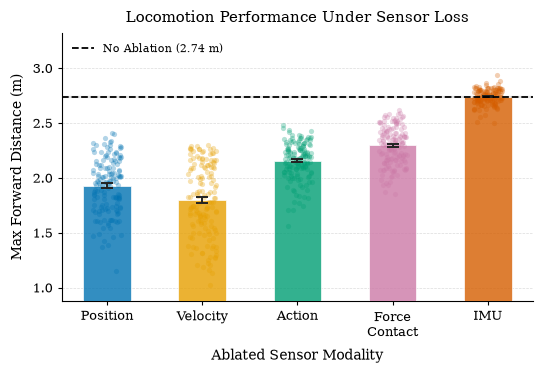

Saved → sensor_loss_performance.pdf / .png


In [21]:
# ── Figure style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         9,
    "axes.labelsize":    10,
    "axes.titlesize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   8,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Data ─────────────────────────────────────────────────────────────────────
sensor_order   = ["pos", "vel", "action", "fc", "IMU"]
display_labels = ["Position", "Velocity", "Action", "Force\nContact", "IMU"]

data_arrays = [performance[s] for s in sensor_order]
means = np.array([np.mean(d) for d in data_arrays])
sems  = np.array([stats.sem(d)  for d in data_arrays])

COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]

# ── Canvas ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 3.8))
x = np.arange(len(sensor_order))
W = 0.50

# Bars
ax.bar(x, means, width=W, color=COLORS, alpha=0.80,
       edgecolor="white", linewidth=0.6, zorder=3)

# Error bars (±1 SEM)
ax.errorbar(x, means, yerr=sems, fmt="none",
            ecolor="#222222", elinewidth=1.4, capsize=4, capthick=1.4, zorder=5)

# Jitter
rng = np.random.default_rng(0)
for i, (xi, data) in enumerate(zip(x, data_arrays)):
    jitter = rng.uniform(-W * 0.30, W * 0.30, size=len(data))
    ax.scatter(xi + jitter, data,
               color=COLORS[i], alpha=0.30, s=14, linewidths=0, zorder=4)

# ── Baseline reference ────────────────────────────────────────────────────────
bm = np.mean(baseline_all)
bs = stats.sem(baseline_all)
ax.axhline(bm, color="black", linestyle="--", linewidth=1.3, zorder=6,
           label=f"No Ablation ({bm:.2f} m)")
ax.axhspan(bm - bs, bm + bs, color="black", alpha=0.07, zorder=2)

# ── Axes decoration ──────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=9)
ax.set_ylabel("Max Forward Distance (m)", labelpad=6)
ax.set_xlabel("Ablated Sensor Modality", labelpad=6)
ax.set_title("Locomotion Performance Under Sensor Loss", pad=8)

ylo = min(d.min() for d in data_arrays)
yhi = max(d.max() for d in data_arrays)
margin = (yhi - ylo) * 0.08
ax.set_ylim(ylo - margin, yhi + margin * 2.5)

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.45, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_linewidth(0.8)
ax.tick_params(axis="both", length=3, width=0.8)
ax.legend(frameon=False, loc="upper left", fontsize=8)

fig.tight_layout()
fig.savefig("sensor_loss_performance.pdf", dpi=300, bbox_inches="tight")
fig.savefig("sensor_loss_performance.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → sensor_loss_performance.pdf / .png")

## Each policies

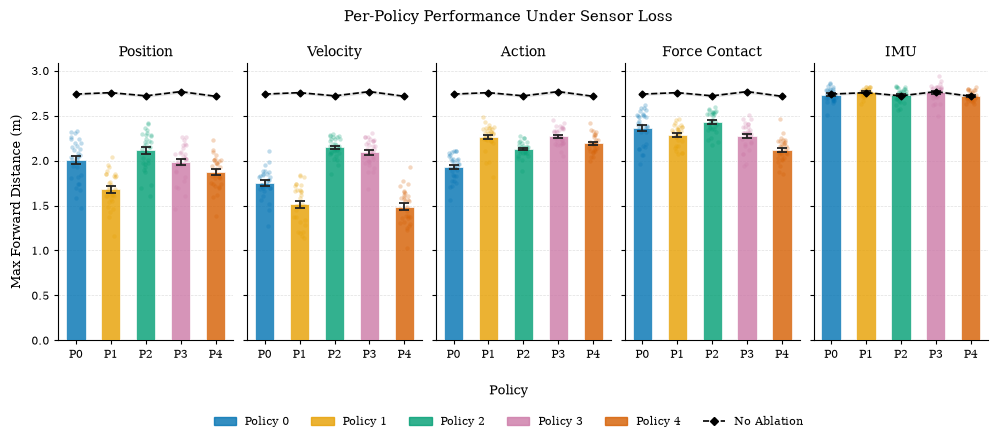

Saved → sensor_loss_per_policy.pdf / .png


In [ ]:
# ── Per-policy data (30 envs × 5 policies, kept separate) ────────────────────
per_policy = {s: [] for s in sensor_loss_name}
for i in range(num_pol):
    for sensor_loss in sensor_loss_name:
        data = np.max(
            np.load(f"../data/dropout/HEBB-pos_vel_action_imu_fc-{i}-bend-drop_{sensor_loss}.npy",
                    allow_pickle=True).item()["pos_x"], 0)
        per_policy[sensor_loss].append(data)   # per_policy[sensor][i] → (30,) array

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":    "serif", "font.size": 9,
    "axes.labelsize": 9, "axes.titlesize": 10,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

sensor_order  = ["pos", "vel", "action", "fc", "IMU"]
sensor_titles = {"pos": "Position", "vel": "Velocity",
                 "action": "Action", "fc": "Force Contact", "IMU": "IMU"}

POL_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]

# Baseline per policy
bm_pol = np.array([np.mean(baseline_per_policy[i]) for i in range(num_pol)])
bs_pol = np.array([stats.sem(baseline_per_policy[i])  for i in range(num_pol)])

# ── Canvas ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(12, 3.6), sharey=True,
                         gridspec_kw={"wspace": 0.08})
fig.suptitle("Per-Policy Performance Under Sensor Loss", fontsize=11, y=1.03)

W   = 0.55
x   = np.arange(num_pol)
rng = np.random.default_rng(0)

for ax, sensor in zip(axes, sensor_order):
    pol_data = per_policy[sensor]
    means    = np.array([np.mean(d) for d in pol_data])
    sems     = np.array([stats.sem(d)  for d in pol_data])

    # Bars
    ax.bar(x, means, width=W, color=POL_COLORS, alpha=0.80,
           edgecolor="white", linewidth=0.6, zorder=3)

    # Error bars
    ax.errorbar(x, means, yerr=sems, fmt="none",
                ecolor="#222222", elinewidth=1.3,
                capsize=3.5, capthick=1.3, zorder=5)

    # Jitter
    for i, d in enumerate(pol_data):
        jitter = rng.uniform(-W * 0.28, W * 0.28, size=len(d))
        ax.scatter(x[i] + jitter, d,
                   color=POL_COLORS[i], alpha=0.25, s=10, linewidths=0, zorder=4)

    # ── Baseline: line connects each policy's baseline mean ───────────────────
    ax.plot(x, bm_pol, color="black", linestyle="--", linewidth=1.2,
            marker="D", markersize=3.5, zorder=6, label="No Ablation")
    ax.fill_between(x, bm_pol - bs_pol, bm_pol + bs_pol,
                    color="black", alpha=0.07, zorder=2)

    ax.set_title(sensor_titles[sensor], pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels([f"P{i}" for i in range(num_pol)])
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.40, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.tick_params(length=3, width=0.8)

axes[0].set_ylabel("Max Forward Distance (m)", labelpad=6)
fig.text(0.5, -0.04, "Policy", ha="center", fontsize=9)

# ── Legend ────────────────────────────────────────────────────────────────────
pol_handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.80) for c in POL_COLORS]
base_handle = plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
                          marker="D", markersize=4)
fig.legend(pol_handles + [base_handle],
           [f"Policy {i}" for i in range(num_pol)] + ["No Ablation"],
           loc="lower center", ncol=6, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.16))

# fig.savefig("sensor_loss_per_policy.pdf", dpi=300, bbox_inches="tight")
# fig.savefig("sensor_loss_per_policy.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → sensor_loss_per_policy.pdf / .png")

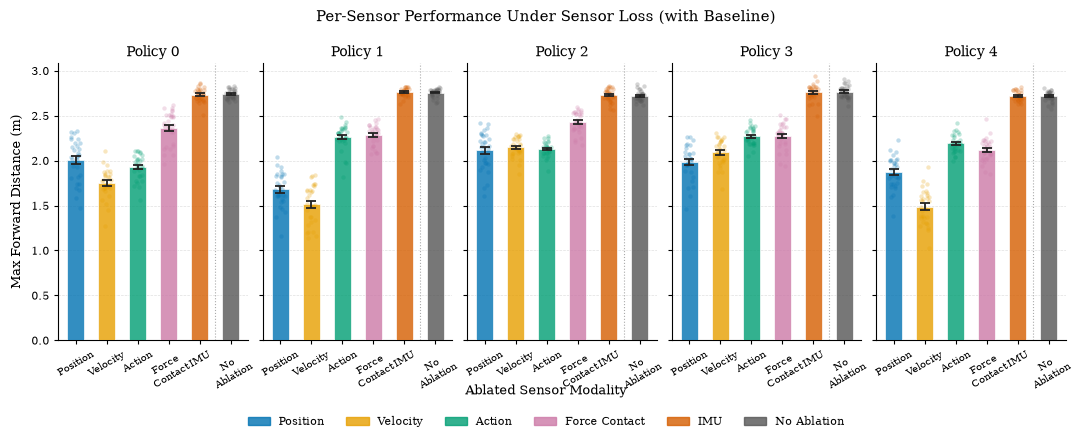

Saved → sensor_loss_per_sensor_with_baseline.pdf / .png


In [32]:
# ── Per-policy: 6 bars per panel (5 sensor ablations + baseline) ─────────────
sensor_order   = ["pos", "vel", "action", "fc", "IMU"]
sensor_labels  = ["Position", "Velocity", "Action", "Force\nContact", "IMU", "No\nAblation"]

SENSOR_COLORS  = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]
BASELINE_COLOR = "#555555"
ALL_COLORS     = SENSOR_COLORS + [BASELINE_COLOR]

fig, axes = plt.subplots(1, 5, figsize=(13, 3.6), sharey=True,
                         gridspec_kw={"wspace": 0.08})
fig.suptitle("Per-Sensor Performance Under Sensor Loss (with Baseline)", fontsize=11, y=1.03)

W   = 0.55
x   = np.arange(len(sensor_labels))   # 6 positions
rng = np.random.default_rng(0)

for pol_idx, ax in enumerate(axes):
    all_data = [per_policy[s][pol_idx] for s in sensor_order] + [baseline_per_policy[pol_idx]]
    means    = np.array([np.mean(d) for d in all_data])
    sems     = np.array([stats.sem(d)  for d in all_data])

    # Bars
    ax.bar(x, means, width=W, color=ALL_COLORS, alpha=0.80,
           edgecolor="white", linewidth=0.6, zorder=3)

    # Error bars
    # ax.errorbar(x, means, yerr=sems, fmt="none",
    ax.errorbar(x, means, yerr=sems, fmt="none",
                ecolor="#222222", elinewidth=1.3,
                capsize=3.5, capthick=1.3, zorder=5)

    # Jitter
    for si, d in enumerate(all_data):
        jitter = rng.uniform(-W * 0.28, W * 0.28, size=len(d))
        ax.scatter(x[si] + jitter, d,
                   color=ALL_COLORS[si], alpha=0.25, s=10, linewidths=0, zorder=4)

    # Thin dotted divider separating ablation bars from baseline bar
    ax.axvline(len(sensor_order) - 0.5, color="#aaaaaa",
               linewidth=0.8, linestyle=":", zorder=7)

    ax.set_title(f"Policy {pol_idx}", pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels(sensor_labels, fontsize=7.5, rotation=30)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.40, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.tick_params(length=3, width=0.8)

axes[0].set_ylabel("Max Forward Distance (m)", labelpad=6)
fig.text(0.5, -0.04, "Ablated Sensor Modality", ha="center", fontsize=9)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.80) for c in ALL_COLORS]
labels  = ["Position", "Velocity", "Action", "Force Contact", "IMU", "No Ablation"]
fig.legend(handles, labels,
           loc="lower center", ncol=6, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.16))

# fig.savefig("sensor_loss_per_sensor_with_baseline.pdf", dpi=300, bbox_inches="tight")
# fig.savefig("sensor_loss_per_sensor_with_baseline.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → sensor_loss_per_sensor_with_baseline.pdf / .png")

## Each Sensor

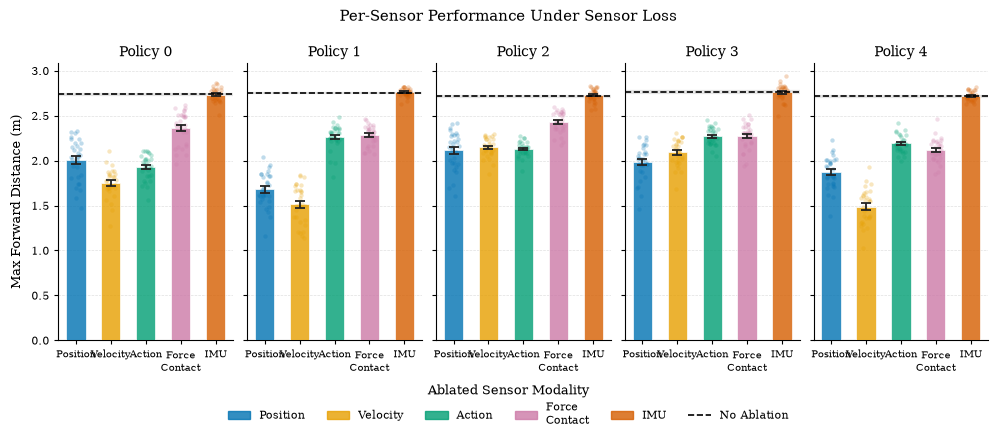

Saved → sensor_loss_per_sensor.pdf / .png


In [ ]:
# ── Canvas: one subplot per policy, bars = sensor modalities ─────────────────
sensor_order   = ["pos", "vel", "action", "fc", "IMU"]
sensor_labels  = ["Position", "Velocity", "Action", "Force\nContact", "IMU"]

SENSOR_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]

fig, axes = plt.subplots(1, 5, figsize=(12, 3.6), sharey=True,
                         gridspec_kw={"wspace": 0.08})
fig.suptitle("Per-Sensor Performance Under Sensor Loss", fontsize=11, y=1.03)

W   = 0.55
x   = np.arange(len(sensor_order))
rng = np.random.default_rng(0)

for pol_idx, ax in enumerate(axes):
    means = np.array([np.mean(per_policy[s][pol_idx]) for s in sensor_order])
    sems  = np.array([stats.sem(per_policy[s][pol_idx])  for s in sensor_order])

    # Bars
    ax.bar(x, means, width=W, color=SENSOR_COLORS, alpha=0.80,
           edgecolor="white", linewidth=0.6, zorder=3)

    # Error bars
    ax.errorbar(x, means, yerr=sems, fmt="none",
                ecolor="#222222", elinewidth=1.3,
                capsize=3.5, capthick=1.3, zorder=5)

    # Jitter
    for si, sensor in enumerate(sensor_order):
        d      = per_policy[sensor][pol_idx]
        jitter = rng.uniform(-W * 0.28, W * 0.28, size=len(d))
        ax.scatter(x[si] + jitter, d,
                   color=SENSOR_COLORS[si], alpha=0.25, s=10, linewidths=0, zorder=4)

    # ── Baseline: horizontal line for this policy ─────────────────────────────
    bm = np.mean(baseline_per_policy[pol_idx])
    bs = stats.sem(baseline_per_policy[pol_idx])
    ax.axhline(bm, color="black", linestyle="--", linewidth=1.2, zorder=6,
               label="No Ablation")
    ax.axhspan(bm - bs, bm + bs, color="black", alpha=0.07, zorder=2)

    ax.set_title(f"Policy {pol_idx}", pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels(sensor_labels, fontsize=7.5)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.40, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.tick_params(length=3, width=0.8)

axes[0].set_ylabel("Max Forward Distance (m)", labelpad=6)
fig.text(0.5, -0.04, "Ablated Sensor Modality", ha="center", fontsize=9)

# ── Legend ────────────────────────────────────────────────────────────────────
sensor_handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.80) for c in SENSOR_COLORS]
base_handle    = plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.2)
fig.legend(sensor_handles + [base_handle],
           sensor_labels + ["No Ablation"],
           loc="lower center", ncol=6, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.16))

# fig.savefig("sensor_loss_per_sensor.pdf", dpi=300, bbox_inches="tight")
fig.savefig("sensor_loss_per_sensor.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → sensor_loss_per_sensor.pdf / .png")

C:\Users\emper\AppData\Local\Temp\ipykernel_59876\1720828159.py:62: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  base_patch  = plt.Rectangle((0, 0), 1, 1, color="#888888", alpha=0.35,


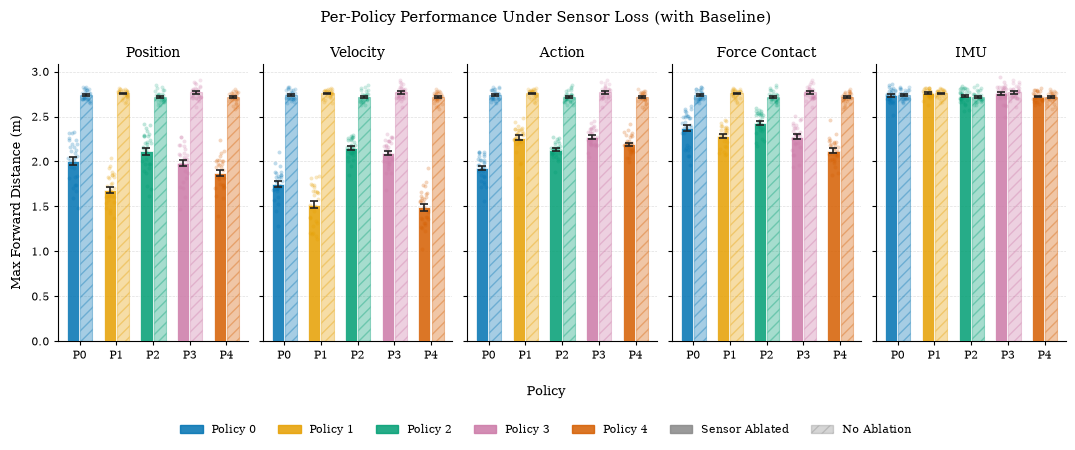

Saved → sensor_loss_per_policy_with_baseline.pdf / .png


In [ ]:
# ── Per-sensor: grouped bars (ablation | baseline) per policy ─────────────────
sensor_order  = ["pos", "vel", "action", "fc", "IMU"]
sensor_titles = {"pos": "Position", "vel": "Velocity",
                 "action": "Action", "fc": "Force Contact", "IMU": "IMU"}

POL_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]

fig, axes = plt.subplots(1, 5, figsize=(13, 3.6), sharey=True,
                         gridspec_kw={"wspace": 0.08})
fig.suptitle("Per-Policy Performance Under Sensor Loss (with Baseline)", fontsize=11, y=1.03)

W   = 0.33   # width of each individual bar within a group
OFF = 0.18   # offset from group centre: ablation left, baseline right
rng = np.random.default_rng(0)
group_x = np.arange(num_pol)   # one group per policy

for ax, sensor in zip(axes, sensor_order):
    for pol_idx in range(num_pol):
        abl_data  = per_policy[sensor][pol_idx]      # (30,) — this policy, this sensor ablated
        base_data = baseline_per_policy[pol_idx]     # (30,) — this policy, no ablation

        abl_mean,  abl_sem  = np.mean(abl_data),  stats.sem(abl_data)
        base_mean, base_sem = np.mean(base_data), stats.sem(base_data)

        xa = group_x[pol_idx] - OFF   # ablation bar
        xb = group_x[pol_idx] + OFF   # baseline bar

        # Ablation bar (solid)
        ax.bar(xa, abl_mean, width=W, color=POL_COLORS[pol_idx],
               alpha=0.85, edgecolor="white", linewidth=0.6, zorder=3)
        ax.errorbar(xa, abl_mean, yerr=abl_sem, fmt="none",
                    ecolor="#222222", elinewidth=1.2, capsize=3, capthick=1.2, zorder=5)
        jitter = rng.uniform(-W * 0.38, W * 0.38, size=len(abl_data))
        ax.scatter(xa + jitter, abl_data,
                   color=POL_COLORS[pol_idx], alpha=0.25, s=8, linewidths=0, zorder=4)

        # Baseline bar (hatched, same policy colour but lighter)
        ax.bar(xb, base_mean, width=W, color=POL_COLORS[pol_idx],
               alpha=0.35, edgecolor=POL_COLORS[pol_idx], linewidth=0.8,
               hatch="///", zorder=3)
        ax.errorbar(xb, base_mean, yerr=base_sem, fmt="none",
                    ecolor="#222222", elinewidth=1.2, capsize=3, capthick=1.2, zorder=5)
        jitter = rng.uniform(-W * 0.38, W * 0.38, size=len(base_data))
        ax.scatter(xb + jitter, base_data,
                   color=POL_COLORS[pol_idx], alpha=0.20, s=8, linewidths=0, zorder=4)

    ax.set_title(sensor_titles[sensor], pad=5)
    ax.set_xticks(group_x)
    ax.set_xticklabels([f"P{i}" for i in range(num_pol)])
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.40, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.tick_params(length=3, width=0.8)

axes[0].set_ylabel("Max Forward Distance (m)", labelpad=6)
fig.text(0.5, -0.04, "Policy", ha="center", fontsize=9)

# ── Legend ────────────────────────────────────────────────────────────────────
pol_handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.85) for c in POL_COLORS]
abl_patch   = plt.Rectangle((0, 0), 1, 1, color="#888888", alpha=0.85)
base_patch  = plt.Rectangle((0, 0), 1, 1, color="#888888", alpha=0.35,
                              hatch="///", edgecolor="#888888")
fig.legend(pol_handles + [abl_patch, base_patch],
           [f"Policy {i}" for i in range(num_pol)] + ["Sensor Ablated", "No Ablation"],
           loc="lower center", ncol=7, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.18))

# fig.savefig("sensor_loss_per_policy_with_baseline.pdf", dpi=300, bbox_inches="tight")
fig.savefig("sensor_loss_per_policy_with_baseline.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → sensor_loss_per_policy_with_baseline.pdf / .png")